# Comparative Analysis: DCGAN vs. WGAN-GP
In this notebook, we analyze the training stability and generative quality of two GAN architectures trained on the CelebA dataset. Instead of running the training loop here, we load the precomputed weights (`.pth`) and metrics (`.npz`) generated by our modular scripts.

## 1. Fréchet Inception Distance (FID) Evolution
The FID measures the distance between the feature distributions of real and generated images. Lower values indicate a higher similarity to the real data distribution.

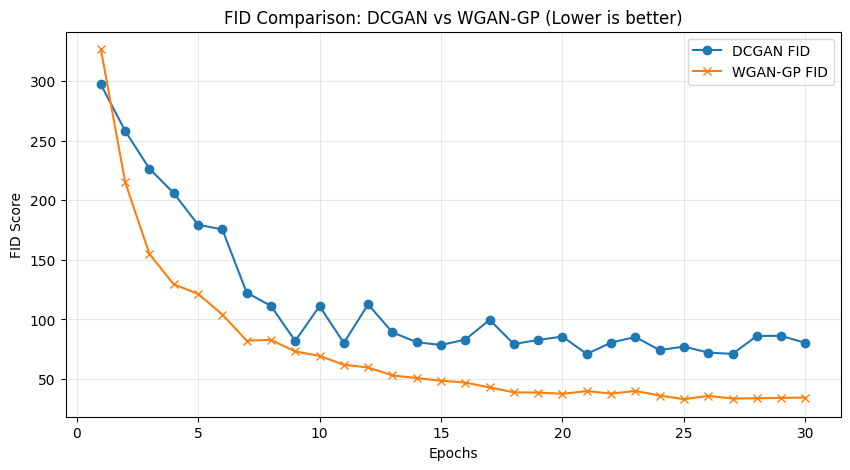

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Load the metrics for both networks using your specific folders
metrics_dcgan = np.load("./results_dcgan/training_metrics.npz")
metrics_wgan = np.load("./results_wgan/training_metrics.npz")

epochs = range(1, len(metrics_dcgan['fid_scores']) + 1)

# Create the comparative plot
plt.figure(figsize=(10, 5))
plt.plot(epochs, metrics_dcgan['fid_scores'], label="DCGAN FID", marker='o')
plt.plot(epochs, metrics_wgan['fid_scores'], label="WGAN-GP FID", marker='x')
plt.title("FID Comparison: DCGAN vs WGAN-GP (Lower is better)")
plt.xlabel("Epochs")
plt.ylabel("FID Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2. Inference and Image Synthesis
Now we instantiate the architectures directly from our modules and load the weights from the final epoch (29) to visually evaluate the results.

Running on device: cuda:0
Running on device: cuda:0


C:\Users\ematm\AppData\Local\Temp\ipykernel_17984\2798105416.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gen_dcgan.load_state_dict(torch.load("./results_dcgan/netG_

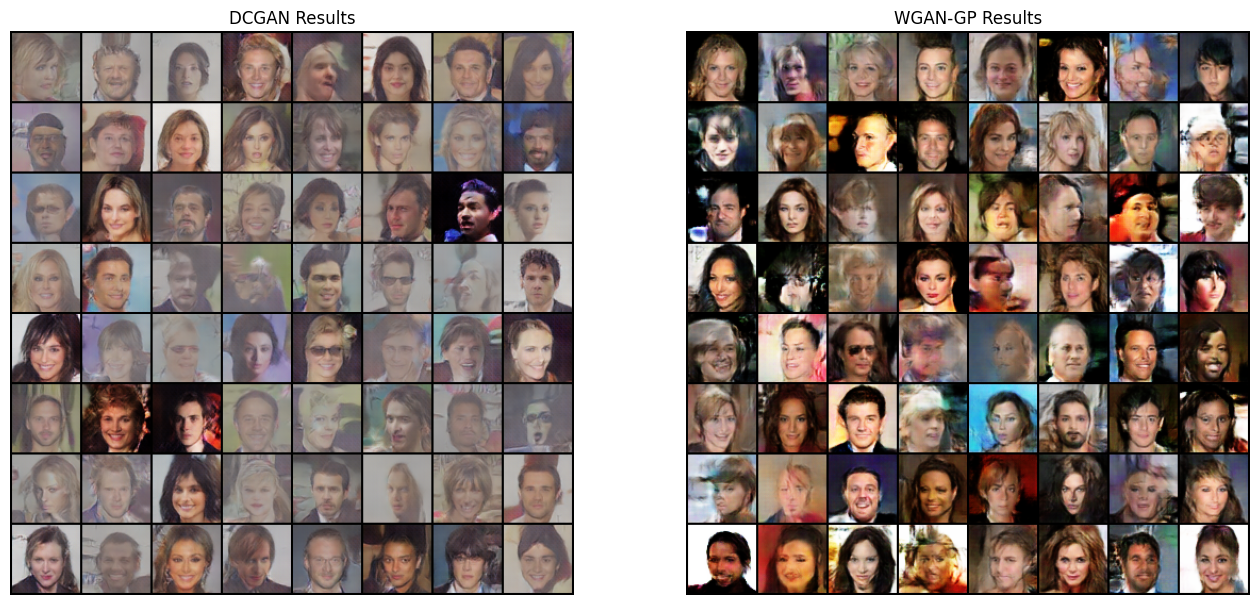

In [3]:
import torchvision.utils as vutils
# Import the classes EXACTLY as defined in your .py scripts
from dcgan import Generator as DCGAN_Gen
from wgan_gp import Generator as WGAN_Gen

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nz = 100 

# Instantiate and load the trained weights from epoch 29
gen_dcgan = DCGAN_Gen(1).to(device)
gen_dcgan.load_state_dict(torch.load("./results_dcgan/netG_epoch_29.pth", map_location=device))
gen_dcgan.eval()

gen_wgan = WGAN_Gen(1).to(device)
gen_wgan.load_state_dict(torch.load("./results_wgan/netG_epoch_29.pth", map_location=device))
gen_wgan.eval()

# Generate the same latent noise to compare how each network interprets it
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

with torch.no_grad():
    fake_dcgan = gen_dcgan(fixed_noise).cpu()
    fake_wgan = gen_wgan(fixed_noise).cpu()

# Side-by-side visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
ax1.imshow(np.transpose(vutils.make_grid(fake_dcgan, padding=2, normalize=True), (1,2,0)))
ax1.set_title("DCGAN Results")
ax1.axis("off")

ax2.imshow(np.transpose(vutils.make_grid(fake_wgan, padding=2, normalize=True), (1,2,0)))
ax2.set_title("WGAN-GP Results")
ax2.axis("off")
plt.show()